In [1]:
import os
import glob
import time
import warnings
warnings.filterwarnings("ignore")
import mlx.core as mx
import coremltools as ct
import coremltools.optimize.coreml as cmo

from nuscenes.nuscenes import NuScenes
from nuscenes.utils.geometry_utils import view_points

import torch
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.ops import nms
from torchmetrics.detection.mean_ap import MeanAveragePrecision

from ultralytics import YOLO
from ultralytics.data.augment import LetterBox
from PIL import Image
import cv2

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kurtosis, entropy

from tqdm import tqdm

scikit-learn version 1.8.0 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
Torch version 2.11.0 has not been tested with coremltools. You may run into unexpected errors. Torch 2.7.0 is the most recent version that has been tested.


### 1. Check System Hardware

In [2]:
def check_m4_power():
    print(f"PyTorch Version: {torch.__version__}")
    
    # Check for Apple GPU (MPS) support - Apple Nueral Engine (ANE)
    if torch.backends.mps.is_available():
        print("PyTorch MPS (Metal Performance Shaders) is available.")
    else:
        print("MPS not found. Check your macOS version.")

    # Check MLX (Apple's native framework)
    print(f"MLX Device: {mx.default_device()}")
    print("MLX is ready for silicon-native optimization.")

if __name__ == "__main__":
    check_m4_power()

PyTorch Version: 2.11.0
PyTorch MPS (Metal Performance Shaders) is available.
MLX Device: Device(gpu, 0)
MLX is ready for silicon-native optimization.


### 2. Get Model

In [3]:
def load_model():
    print("--- Initializing Perception Backbones ---")
    
    # 1. MobileNetV3 Small
    mbv3 = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
    mbv3.eval()
    print("MobileNetV3 Small loaded.")

    # 2. EfficientNet-B0
    effnet = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    effnet.eval()
    print("EfficientNet-B0 loaded.")

    # 3. YOLOv8 Medium
    yolo = YOLO('models/yolov8m.pt') 
    print("YOLOv8 Medium loaded.")
    
    return mbv3, effnet, yolo

if __name__ == "__main__":
    load_model()

--- Initializing Perception Backbones ---
MobileNetV3 Small loaded.
EfficientNet-B0 loaded.
YOLOv8 Medium loaded.


### 3. Weight Sensitivity Profiling for YOLOv8 Medium

--- Initializing Perception Backbones ---
MobileNetV3 Small loaded.
EfficientNet-B0 loaded.
YOLOv8 Medium loaded.

--- Profiling: MobileNetV3 ---
Global Range: [-5.1563, 4.9017]
Global Standard Deviation: 0.1190
Global Kurtosis: 22.8778

--- Profiling: EfficientNet-B0 ---
Global Range: [-2.5309, 3.6358]
Global Standard Deviation: 0.0742
Global Kurtosis: 15.5494

--- Profiling: YOLOv8 ---
Global Range: [-0.4062, 15.0000]
Global Standard Deviation: 0.0094
Global Kurtosis: 887435.9375


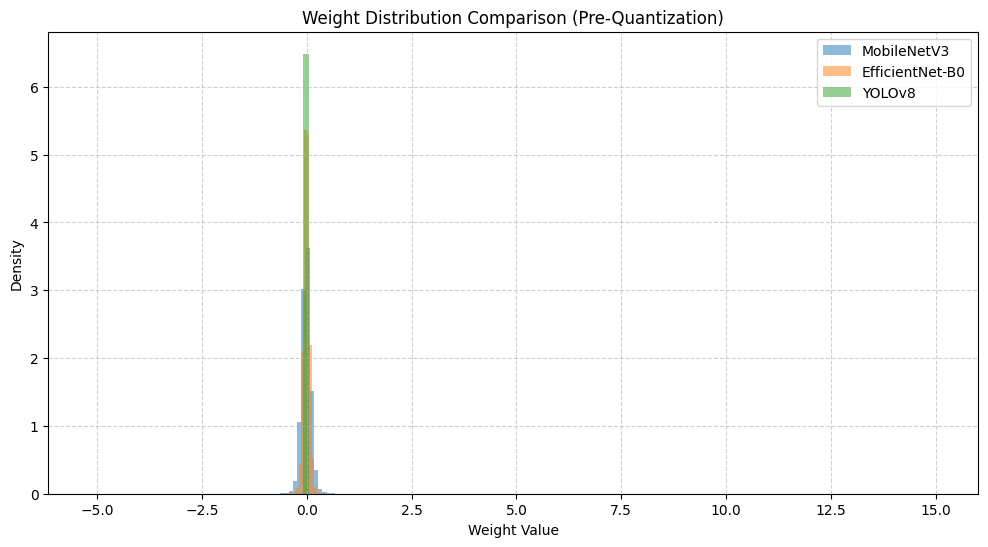


--- Profiling: MobileNet ---
Layer Name                               | Kurtosis        | Range          
---------------------------------------------------------------------------
features.0.0.weight                      | 12.09           | 10.0580        
features.1.block.0.0.weight              | 2.67            | 8.1873         
features.1.block.1.fc1.weight            | 17.45           | 0.0037         
features.1.block.1.fc2.weight            | 6.28            | 0.0027         
features.1.block.2.0.weight              | 5.29            | 7.1430         
features.2.block.0.0.weight              | 6.80            | 5.9072         
features.2.block.1.0.weight              | 2.60            | 4.2526         
features.2.block.2.0.weight              | 9.84            | 6.9122         
features.3.block.0.0.weight              | 13.41           | 5.3559         
features.3.block.1.0.weight              | 5.54            | 4.2274         
features.3.block.2.0.weight              | 3.98

In [4]:
def profile_weights(model, model_name):
    print(f"\n--- Profiling: {model_name} ---")
    all_weights = []
    layer_stats = []

    # Iterate through layers
    for name, param in model.named_parameters():
        if 'weight' in name and len(param.shape) >= 2:
            w = param.data.cpu().numpy().flatten()
            
            # Statistical Metrics
            w_min, w_max = np.min(w), np.max(w)
            w_std = np.std(w)
            w_kurt = kurtosis(w)
            
            layer_stats.append({
                'layer': name,
                'min': w_min,
                'max': w_max,
                'range': w_max - w_min,
                'std': w_std,
                'kurtosis': w_kurt
            })
            all_weights.extend(w)

    # Convert to numpy for global analysis
    all_weights = np.array(all_weights)
    
    print(f"Global Range: [{all_weights.min():.4f}, {all_weights.max():.4f}]")
    print(f"Global Standard Deviation: {np.std(all_weights):.4f}")
    print(f"Global Kurtosis: {kurtosis(all_weights):.4f}")
    
    return all_weights, layer_stats

def plot_distributions(weights_dict):
    plt.figure(figsize=(12, 6))
    for name, weights in weights_dict.items():
        plt.hist(weights, bins=100, alpha=0.5, label=name, density=True)
    
    plt.title("Weight Distribution Comparison (Pre-Quantization)")
    plt.xlabel("Weight Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

def profile_by_architecture(yolo_model):
    print("\n--- Architectural Profiling: YOLOv8m ---")
    
    # Storage for weights
    buckets = {
        "Backbone (0-9)": [],
        "Neck (10-21)": [],
        "Head (22)": []
    }

    # Iterate through parameters and categorize
    for name, param in yolo_model.named_parameters():
        if 'weight' in name and len(param.shape) >= 2:
            w = param.data.cpu().numpy().flatten()
            
            # Extract layer index from name (e.g., 'model.22.cv2.0.weight' -> 22)
            try:
                parts = name.split('.')
                idx = int(parts[1]) if parts[0] == 'model' else int(parts[0])
                
                if 0 <= idx <= 9:
                    buckets["Backbone (0-9)"].extend(w)
                elif 10 <= idx <= 21:
                    buckets["Neck (10-21)"].extend(w)
                elif idx == 22:
                    buckets["Head (22)"].extend(w)
            except (ValueError, IndexError):
                continue

    # Print Results Table
    print(f"{'Section':<20} | {'Kurtosis':<15} | {'Range':<15} | {'Std Dev':<10}")
    print("-" * 70)

    results = {}
    for section, weights in buckets.items():
        w_array = np.array(weights)
        k = kurtosis(w_array)
        r = np.max(w_array) - np.min(w_array)
        s = np.std(w_array)
        
        print(f"{section:<20} | {k:<15.2f} | {r:<15.4f} | {s:<10.4f}")
        results[section] = w_array

    return results

if __name__ == "__main__":
    mbv3, effnet, yolo = load_model()
    
    # Profile all three
    w_mbv3, stats_mbv3 = profile_weights(mbv3, "MobileNetV3")
    w_effnet, stats_effnet = profile_weights(effnet, "EfficientNet-B0")
    w_yolo, stats_yolo = profile_weights(yolo.model, "YOLOv8")

    plot_distributions({
        "MobileNetV3": w_mbv3,
        "EfficientNet-B0": w_effnet,
        "YOLOv8": w_yolo
    })

    print("\n--- Profiling: MobileNet ---")
    print(f"{'Layer Name':<40} | {'Kurtosis':<15} | {'Range':<15}")
    print("-" * 75)
    for layer in stats_mbv3:
        print(f"{layer['layer']:<40} | {layer['kurtosis']:<15.2f} | {layer['range']:<15.4f}")
    print("-" * 75)

    print("\n--- Profiling: EfficientNet ---")
    print(f"{'Layer Name':<40} | {'Kurtosis':<15} | {'Range':<15}")
    print("-" * 75)
    for layer in stats_effnet:
        print(f"{layer['layer']:<40} | {layer['kurtosis']:<15.2f} | {layer['range']:<15.4f}")
    print("-" * 75)  

    print("\n--- Profiling: YOLO ---")
    print(f"{'Layer Name':<40} | {'Kurtosis':<15} | {'Min':<15} | {'Max':<15} | {'Range':<15}")
    print("-" * 105)
    for layer in stats_yolo:
        print(f"{layer['layer']:<40} | {layer['kurtosis']:<15.2f} | {layer['min']:<15.4f} | {layer['max']:<15.4f} | {layer['range']:<15.4f}")
    print("-" * 105)

    arch_weights = profile_by_architecture(yolo.model)

**YOLO Architecture**

**Weight Distribution Analysis for YOLOv8**

**BACKBONE**

The Backbone has a relatively small range (-0.40 <-> 0.49). Usually the initial layers are robust to outliers. While the Kurtosis is 69, the absolute boundaries are tight enough that a standard scale won't cause massive rounding noise.

We will be using Min-Max PTQ

**NECK**

The Neck has lowest Kurtosis of 24 and smallest range of 0.44. By clipping the outermost 0.01% of values on both the tails, we ensure that the remaining 99.99% of weights occupy more "levels" of the INT8 range and are well reprsented. This maximizes Precision for the feature fusion layers (Neck layers), which is critical for detecting small or distant objects.

We will be using Clipped Min-Max PTQ

**HEAD**

The 372K Kurtosis in the Head is almost entirely driven by a single, unique layer: **model.22.dfl.conv.weight**. The range of this layer - DFL (Distribution Focal Loss) is 15, almost every other layer has a range under 1.0. In YOLOv8, the DFL layer is used to predict the bounding box coordinates. Its weights are often fixed or initialized to represent a sequence [0, 1, 2, ...., 15]. It has a negative Kurtosis (-1.21). This means it’s a "flat" or uniform distribution, not a spike. 

If we use a single global statistics for the whole model, we have to use a bucket that fits the 15 weight (max weight from Head). For the Neck (where weights are only 0.4), they would be represented by just a few integer levels out of available INT8 bins. This is known as **Rounding Error**. We are effectively turning our high precision Neck into blurry low resolution.

The DFL layer (with its 15.0 range) is a statistical outlier. If we use Min-Max here, the entire Head’s scale would be dictated by the DFL layer, leaving the other Head layers with almost no representation.

Also, many of the cv2 layers in Head have high kurtosis. Eg. **model.22.cv2.1.0.conv.weight** - Most weights are near zero (range is 0.3), but a few weights are far out in the tails. If we use MinMax quantization on this layer, these outlier weights will pull the scale so wide that the "zero-peak" (where most of the information lives) will lose all resolution.

For this layer we will use KL-Divergence Threshold PTQ.

DFL will remain in full precision. This is known as **Mixed Precison**. By keeping DFL in FP16, we allow the KL Threshold to focus entirely on the cv layers. Since you're using KL Thresholding for the rest of the Head, we are perfectly managing those layers with Kurtosis between 30 and 80. The KL algorithm will "snip" the very tips of those long tails to make sure the "meat" of the distribution is represented with high resolution.

## YOLO V8 Medium

### 1. Backbone Quantization - Asymmetric Min Max Scaling

Backbone quantization is very critical because if the Backbone starts propogating high quantization error due to Min-Max rounding, the Neck and Head will have no chance of being accurate, regardless of how we quantize them.

Steps involved ->

- Simulate "Fake Quantization"
  
- Compute scale factor (S) -> depends on max and min of each weight tensor in layers 0-9 

- Compute zero point (Z) -> depends on S

- Testing on a sample of 100 ADAS images

- Computing quantization error and tensor similarity of output - Original FP32 Model as the "Ground Truth" and see how much the quantized version deviates from it.

By replacing module.weight.data with the de-quantized values, we are effectively "injecting" the rounding noise of INT8 into our FP32 model. The weight values have been "crushed" into 256 discrete steps. Fake quantization only modifies the weights on RAM (in memory). Even if we save the model right now, our silicon chip will still use its "Floating Point" brain to do the math. It will just be doing math with numbers that happen to be rounded.


The code below only quantizes the Weights. Weights are constant, so we can calculate their Min-Max once and forget it. Activations are dynamic. To "perform" quantization on activations for the backbone, we would need to insert a Quantization Observer (a hook) that clips the signal as it flows through (Next Phase of the project)

In [5]:
MODEL_PATH = 'models/yolov8m.pt'
BIT_WIDTH = 8
Q_MIN, Q_MAX = -128, 127
NUM_VAL_IMAGES = 100  # ADAS validation sampples
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

# DEFINE QUANTIZATION LOGIC
def quantize_min_max(tensor, q_min, q_max):
    """Performs Asymmetric Min-Max Fake Quantization."""
    min_val = tensor.min().item()
    max_val = tensor.max().item()
    
    # Calculate Scale (S)
    scale = (max_val - min_val) / (q_max - q_min)
    if scale == 0:
        return tensor, 0, 0
    
    # Calculate Zero-point (Z)
    zero_point = round(q_min - (min_val / scale))
    
    # Quantize and Clamp
    q_tensor = torch.clamp(torch.round(tensor / scale + zero_point), q_min, q_max)
    
    # De-quantize (Fake Quantization)
    dq_tensor = (q_tensor - zero_point) * scale
    return dq_tensor, scale, zero_point

# Preprocess ADAS images to YOLO format
def image_preprocess(img_raw):
    img_raw = np.array(img_raw.convert("RGB"))
    img_lb = letterbox(image=img_raw)
    img_t = torch.from_numpy(img_lb.transpose((2, 0, 1))).to(device).float().unsqueeze(0) / 255.0

    return img_t

# INITIALIZE MODELS
# Reference Model (Original FP32)
model_ref = YOLO(MODEL_PATH).model.to(device).eval()

# Quantized Model (The one we will modify)
model_quant = YOLO(MODEL_PATH).model.to(device).eval()

# PERFORM BACKBONE QUANTIZATION
print("\n--- Quantizing Backbone (Layers 0-9) ---")
with torch.no_grad():
    for name, module in model_quant.named_modules():
        parts = name.split('.')
        if len(parts) >= 2 and parts[0] == 'model':
            try:
                idx = int(parts[1])
                # Target layers 0-9 and only Convolution weights
                if 0 <= idx <= 9 and hasattr(module, 'weight'):
                    w = module.weight.data
                    # print(f"quantizing layer: {name}")
                    w_q, s, z = quantize_min_max(w, Q_MIN, Q_MAX)
                    module.weight.data = w_q
            except ValueError as e:
                print(e)
                continue
    print('Backbone Quantization Completed')

# VALIDATION LOOP
# Setup Letterbox (standard YOLO preprocessing)
letterbox = LetterBox(new_shape=640, stride=32, auto=False)
sample_images = glob.glob("../AV/data/sets/nuscenes/samples/CAM_FRONT/*.jpg")[:NUM_VAL_IMAGES]

mse_scores = []
cosine_scores = []

if not sample_images:
    print("Error: No nuScenes images found. Check path!")
else:
    print(f"\n--- Comparing Outputs on ADAS {NUM_VAL_IMAGES} nuScenes frames ---")
    with torch.no_grad():
        for img_path in tqdm(sample_images):
            # Preprocess
            img_raw = Image.open(img_path)
            img_t = image_preprocess(img_raw)

            # Forward Pass (both models)
            # YOLOv8 returns a tuple, index 0 is the raw detection tensor
            out_ref = model_ref(img_t)[0]
            out_q = model_quant(img_t)[0]

            # Calculate Error Metrics
            mse = torch.nn.functional.mse_loss(out_ref, out_q).item()
            # Cosine similarity measures how well the "logic" is preserved
            cos = torch.nn.functional.cosine_similarity(out_ref.flatten(), out_q.flatten(), dim=0).item()
            
            mse_scores.append(mse)
            cosine_scores.append(cos)

    # FINAL REPORT
    avg_mse = np.mean(mse_scores)
    avg_cos = np.mean(cosine_scores)

    print("\n" + "="*60)
    print(f"{'METRIC':<30} | {'VALUE'}")
    print("-" * 60)
    print(f"{'Mean Squared Error (MSE)':<30} | {avg_mse:.8f}")
    print(f"{'Cosine Similarity (Fidelity)':<30} | {avg_cos:.8f}")
    print("="*60)


--- Quantizing Backbone (Layers 0-9) ---
Backbone Quantization Completed

--- Comparing Outputs on ADAS 100 nuScenes frames ---


100%|█| 100/100 


METRIC                         | VALUE
------------------------------------------------------------
Mean Squared Error (MSE)       | 0.36423057
Cosine Similarity (Fidelity)   | 0.99994728


### 2. Backbone + Neck Quantization - Clipped Min Max Scaling

The logic here is that we no longer want a single "freak" outlier define the boundaries. Instead, we "snip" the top and bottom 0.01% of the weights. This forces the 256 INT8 levels to describe the "meat" of the distribution with much higher resolution.

We ignore the extreme 0.01% of weights. The other 99.99% of weights which do the heavy lifting in these layers get to "stretch out" and use more of the 256 available integer levels (In the presence of outliers they will only use a few levels - Rounding Error).

In [6]:
# Configurations
MODEL_PATH = 'models/yolov8m.pt'
Q_MIN, Q_MAX = -128, 127
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

# Quantization Functions
def quantize_asymmetric(tensor, min_val, max_val, q_min, q_max):
    """Core logic to quantize a tensor given specific min/max boundaries."""
    scale = (max_val - min_val) / (q_max - q_min)
    if scale == 0:
        return tensor
    
    zero_point = round(q_min - (min_val / scale))
    q_tensor = torch.clamp(torch.round(tensor / scale + zero_point), q_min, q_max)
    return (q_tensor - zero_point) * scale

def get_clipped_bounds(tensor, percentile=0.0001):
    """Finds the values at the specified percentiles (e.g., 0.01% and 99.99%)."""
    # Move to CPU for stable quantile calculation
    flat_w = tensor.detach().cpu().flatten()
    lower_bound = torch.quantile(flat_w, percentile).item()
    upper_bound = torch.quantile(flat_w, 1.0 - percentile).item()
    return lower_bound, upper_bound

# Initialize Models
model_ref = YOLO(MODEL_PATH).model.to(device).eval()
model_quant = YOLO(MODEL_PATH).model.to(device).eval()

# 4. Apply Architectural Strategy
print("\n--- Applying Architectural Quantization Strategy ---")
with torch.no_grad():
    for name, module in model_quant.named_modules():
        parts = name.split('.')
        if len(parts) >= 2 and parts[0] == 'model':
            try:
                idx = int(parts[1])
                if not hasattr(module, 'weight'):
                    continue
                
                w = module.weight.data
                
                # BACKBONE (0-9): Standard Min-Max
                if 0 <= idx <= 9:
                    w_q = quantize_asymmetric(w, w.min().item(), w.max().item(), Q_MIN, Q_MAX)
                    module.weight.data = w_q
                
                # NECK (10-21): Clipped Min-Max (0.01% Clipping)
                elif 10 <= idx <= 21:
                    c_min, c_max = get_clipped_bounds(w, percentile=0.0001)
                    w_q = quantize_asymmetric(w, c_min, c_max, Q_MIN, Q_MAX)
                    module.weight.data = w_q
                    
            except ValueError as e:
                print(e)
                continue
    print("Backbone + Neck Quantization Completed")

# 5. Validation Loop
cosine_scores = []
mse_scores = []

print(f"\n--- Validating Backbone + Neck on ADAS {len(sample_images)} frames ---")
with torch.no_grad():
    for img_path in tqdm(sample_images):
        img_raw = Image.open(img_path)
        img_t = image_preprocess(img_raw)

        out_ref = model_ref(img_t)[0]
        out_q = model_quant(img_t)[0]

        mse = torch.nn.functional.mse_loss(out_ref, out_q).item()
        cos = torch.nn.functional.cosine_similarity(out_ref.flatten(), out_q.flatten(), dim=0).item()

        mse_scores.append(mse)
        cosine_scores.append(cos)

avg_mse = np.mean(mse_scores)
avg_cos = np.mean(cosine_scores)

print("\n" + "="*60)
print(f"{'METRIC':<30} | {'VALUE'}")
print("-" * 60)
print(f"{'Mean Squared Error (MSE)':<30} | {avg_mse:.8f}")
print(f"{'Cosine Similarity (Fidelity)':<30} | {avg_cos:.8f}")
print("="*60)


--- Applying Architectural Quantization Strategy ---
Backbone + Neck Quantization Completed

--- Validating Backbone + Neck on ADAS 100 frames ---


100%|█| 100/100 


METRIC                         | VALUE
------------------------------------------------------------
Mean Squared Error (MSE)       | 1.38658184
Cosine Similarity (Fidelity)   | 0.99979934


When we "snip" the top 0.01% of weights in the Neck, we are technically throwing away some numerical data. This increases the absolute error (MSE). Despite that numerical error, our Cosine Similarity (0.9998) proves that the meaning of the features hasn't changed. By sacrificing those extreme outlier weights, we gave the rest of the feature fusion logic much higher resolution.

The fact that our feature similarity only dropped by ~0.0001 after adding 12 more layers (the Neck) is a direct proof to the "well-behaved" nature of the YOLOv8 Neck. It also confirms that our clipping threshold wasn't too aggressive and it is working fine.

### 3. Backbone + Neck + Head Quantization - KL Threshold Scaling

The goal here is to preserve the precision of the model's spatial coordinates (DFL layer - Bonding Boxes) while cleaning up the noise in its classification and bounding box branches.

By quantizing the Head layers individually, the massive 15.0 range of the DFL weights no longer dictates the scale for the smaller 0.3 range cv weights.

By using the KL-Divergence search, we find the "mathematical compromise" for the layers with 80+ Kurtosis. It ignores the freakishly long tails of those weight distributions to ensure that the core signal has maximum bit-resolution.

Keeping the DFL layer in full precison ensures our bounding box predictions aren't "quantized" into grid steps. **This prevents the "pixel-jitter" that often kills accuracy in autonomous driving datasets like nuScenes**

In [7]:
def get_kl_threshold(tensor, num_bins=2048):
    """
    Finds the clipping threshold that minimizes KL-Divergence between 
    the original distribution and the quantized distribution.
    """
    w = tensor.detach().cpu().numpy().flatten()
    abs_w = np.abs(w)
    max_val = np.max(abs_w)
    
    # Create histogram of absolute weights
    hist, bin_edges = np.histogram(abs_w, bins=num_bins, range=(0, max_val))
    hist = hist / np.sum(hist) # Normalize
    
    # Search for the optimal threshold (moving from 50% of max to 100%)
    best_kl = float('inf')
    best_threshold = max_val
    
    # Check candidates for clipping
    for i in range(num_bins // 2, num_bins):
        threshold = bin_edges[i]
        
        # Simulate quantization mapping for this threshold
        # We simplify by comparing the histogram distributions
        p = hist.copy()
        # Everything beyond threshold is clipped into the last bin
        p[i:] = 0
        p[i-1] += np.sum(hist[i:])
        
        # Q is our "quantized" approximation (uniform distribution in 127 bins)
        # For weights, we look for the threshold that loses the least information
        q = np.zeros_like(p)
        q[:i] = np.mean(hist[:i]) # Simplified uniform distribution of quantized bins
        
        # Add small epsilon to avoid log(0)
        kl = entropy(hist + 1e-12, q + 1e-12)
        
        if kl < best_kl:
            best_kl = kl
            best_threshold = threshold
            
    return -best_threshold, best_threshold

# Initialize Models
model_ref = YOLO(MODEL_PATH).model.to(device).eval()
model_quant = YOLO(MODEL_PATH).model.to(device).eval()

# Apply Final Architectural Strategy
print("\n--- Executing Final Architectural Strategy ---")
with torch.no_grad():
    for name, module in model_quant.named_modules():
        if not hasattr(module, 'weight'):
            continue
        parts = name.split('.')
        idx = int(parts[1]) if parts[0] == 'model' else -1
        
        w = module.weight.data
        
        # A. BACKBONE (0-9): Min-Max
        if 0 <= idx <= 9:
            w_q = quantize_asymmetric(w, w.min().item(), w.max().item(), Q_MIN, Q_MAX)
            module.weight.data = w_q
        
        # B. NECK (10-21): Clipped Min-Max (0.01%)
        elif 10 <= idx <= 21:
            w_flat = w.detach().cpu()
            c_min = torch.quantile(w_flat, 0.0001).item()
            c_max = torch.quantile(w_flat, 0.9999).item()
            module.weight.data = quantize_asymmetric(w, c_min, c_max, Q_MIN, Q_MAX)
            
        # C. HEAD (22): KL Threshold & DFL Isolation
        elif idx == 22:
            if 'dfl' in name:
                # SKIP DFL - Keep in FP16 to avoid coordinate "rounding"
                print(f"Skipping DFL Quantization: {name} (Keeping FP16)")
            else:
                # APPLY KL DIVERGENCE to cv2 and cv3 layers
                k_min, k_max = get_kl_threshold(w)
                module.weight.data = quantize_asymmetric(w, k_min, k_max, Q_MIN, Q_MAX)
    print("All Layers Quantization Completed")

# 5. Validation Loop
cosine_scores = []
mse_scores = []

print("\n--- Final Fidelity Validation (Backbone + Neck + Head) ---")
with torch.no_grad():
    for img_path in tqdm(sample_images):
        img_raw = Image.open(img_path)
        img_t = image_preprocess(img_raw)

        out_ref = model_ref(img_t)[0]
        out_q = model_quant(img_t)[0]

        mse_scores.append(torch.nn.functional.mse_loss(out_ref, out_q).item())
        cosine_scores.append(torch.nn.functional.cosine_similarity(out_ref.flatten(), out_q.flatten(), dim=0).item())

avg_mse = np.mean(mse_scores)
avg_cos = np.mean(cosine_scores)

print("\n" + "="*60)
print(f"{'METRIC':<30} | {'VALUE'}")
print("-" * 60)
print(f"{'Mean Squared Error (MSE)':<30} | {avg_mse:.8f}")
print(f"{'Cosine Similarity (Fidelity)':<30} | {avg_cos:.8f}")
print("="*60)


--- Executing Final Architectural Strategy ---
Skipping DFL Quantization: model.22.dfl.conv (Keeping FP16)
All Layers Quantization Completed

--- Final Fidelity Validation (Backbone + Neck + Head) ---


100%|█| 100/100 


METRIC                         | VALUE
------------------------------------------------------------
Mean Squared Error (MSE)       | 1.46283944
Cosine Similarity (Fidelity)   | 0.99978827


Consine similarity is high - Detections will be spatially consistent with the original FP32 model.

MSE - This is the inevitable noise of rounding 32-bit floats into 8-bit bins. Because Similarity is high, this MSE is harmless noise.

Because we clipped the outliers, channels now have much more "room" in the 256 INT8 levels. Their precision is preserved, allowing the model to see small, distant objects clearly.

#### Checking Bounding Box stability

--- Generating Visual Comparison for ../AV/data/sets/nuscenes/samples/CAM_FRONT/n015-2018-11-21-19-38-26+0800__CAM_FRONT__1542800991912460.jpg ---

image 1/1 /Users/pradyumnsrivastava/Documents/ML/QuantaEdge/../AV/data/sets/nuscenes/samples/CAM_FRONT/n015-2018-11-21-19-38-26+0800__CAM_FRONT__1542800991912460.jpg: 384x640 8 cars, 1 bus, 1 traffic light, 1 clock, 107.7ms
Speed: 4.4ms preprocess, 107.7ms inference, 27.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /Users/pradyumnsrivastava/Documents/ML/QuantaEdge/../AV/data/sets/nuscenes/samples/CAM_FRONT/n015-2018-11-21-19-38-26+0800__CAM_FRONT__1542800991912460.jpg: 384x640 6 cars, 1 bus, 27.8ms
Speed: 1.5ms preprocess, 27.8ms inference, 19.3ms postprocess per image at shape (1, 3, 384, 640)


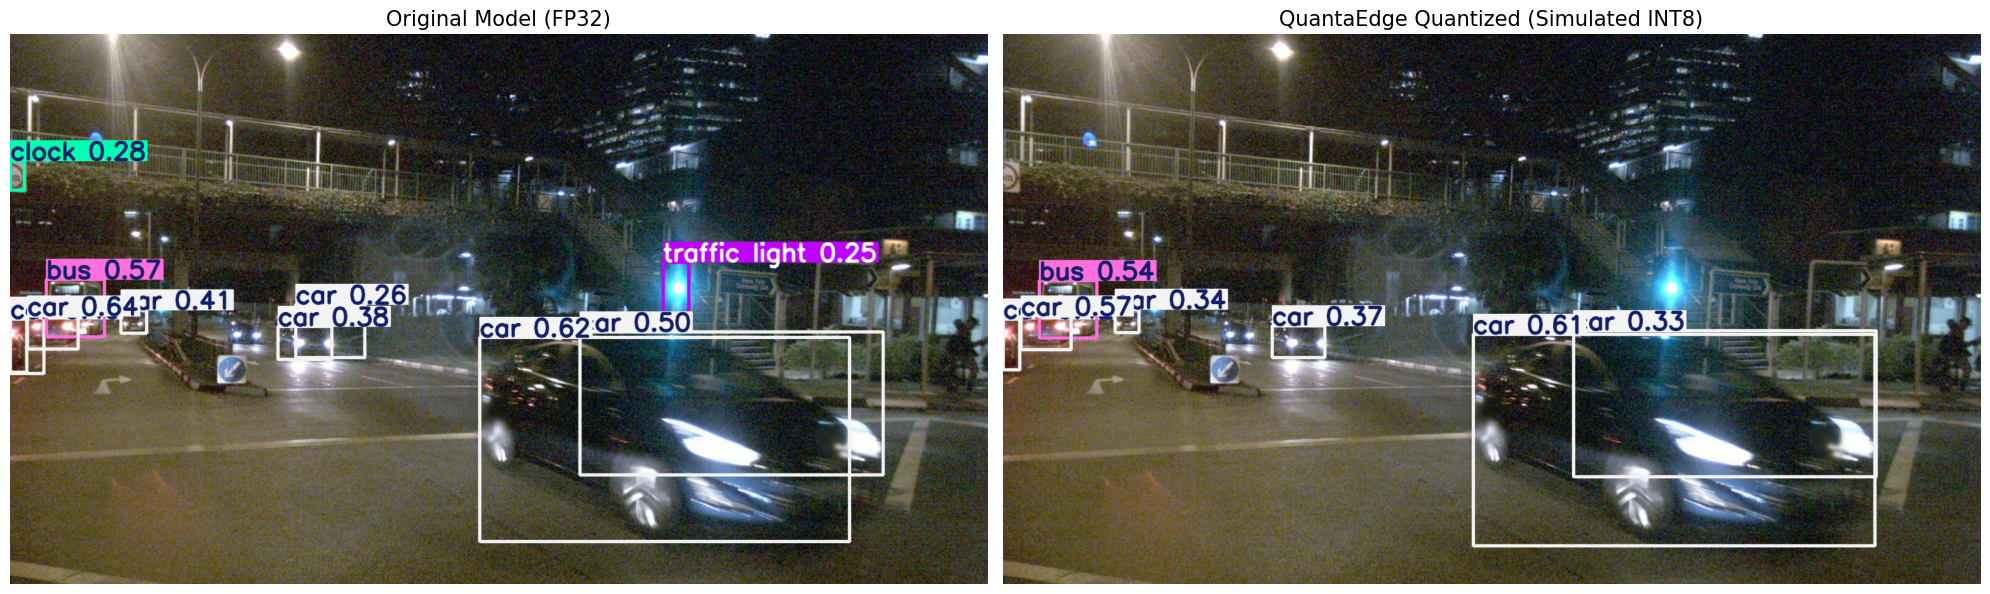

In [8]:
# Select a challenging nuScenes frame
test_image_path = sample_images[10] 

def get_annotated_frame(model_obj, img_path):
    # Run inference
    # Note: We use the .predict() method which handles the internal logic
    results = model_obj.predict(img_path, conf=0.25, device=device)[0]
    
    # Render the boxes onto the image
    return results.plot()

# Prepare the high-level wrapper for the quantized model
# We create a new YOLO object and swap its internal model with our 'model_quant'
quant_wrapper = YOLO(MODEL_PATH)
quant_wrapper.model = model_quant # This is our Backbone+Neck+KL Head model

# Generate Visuals
print(f"--- Generating Visual Comparison for {test_image_path} ---")
img_fp32 = get_annotated_frame(YOLO(MODEL_PATH), test_image_path)
img_int8 = get_annotated_frame(quant_wrapper, test_image_path)

# Plot Side-by-Side
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_fp32, cv2.COLOR_BGR2RGB))
plt.title("Original Model (FP32)", fontsize=15)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_int8, cv2.COLOR_BGR2RGB))
plt.title("QuantaEdge Quantized (Simulated INT8)", fontsize=15)
plt.axis('off')

plt.tight_layout()
plt.show()

Check the edges of the boxes. If our DFL layer had been quantized poorly, we would see the boxes "stepping"—moving in discrete jumps rather than smoothly following the car's contour. Because we kept it in FP32, the boxes should look identical in position.

Can see distant objects as well with some confidence jitters - Neck Quantization worked well.

Because we've rounded the weights, the "noise" in the model's brain that was barely high enough to trigger those false detections has been smoothed out (clock and traffic lights not detected by the quantized model)

--- Generating Visual Comparison for ../AV/data/sets/nuscenes/samples/CAM_FRONT/n008-2018-08-01-15-16-36-0400__CAM_FRONT__1533151619912458.jpg ---

image 1/1 /Users/pradyumnsrivastava/Documents/ML/QuantaEdge/../AV/data/sets/nuscenes/samples/CAM_FRONT/n008-2018-08-01-15-16-36-0400__CAM_FRONT__1533151619912458.jpg: 384x640 1 person, 1 bicycle, 19 cars, 1 truck, 27.5ms
Speed: 1.4ms preprocess, 27.5ms inference, 18.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /Users/pradyumnsrivastava/Documents/ML/QuantaEdge/../AV/data/sets/nuscenes/samples/CAM_FRONT/n008-2018-08-01-15-16-36-0400__CAM_FRONT__1533151619912458.jpg: 384x640 1 person, 1 bicycle, 16 cars, 1 truck, 27.4ms
Speed: 1.6ms preprocess, 27.4ms inference, 17.8ms postprocess per image at shape (1, 3, 384, 640)


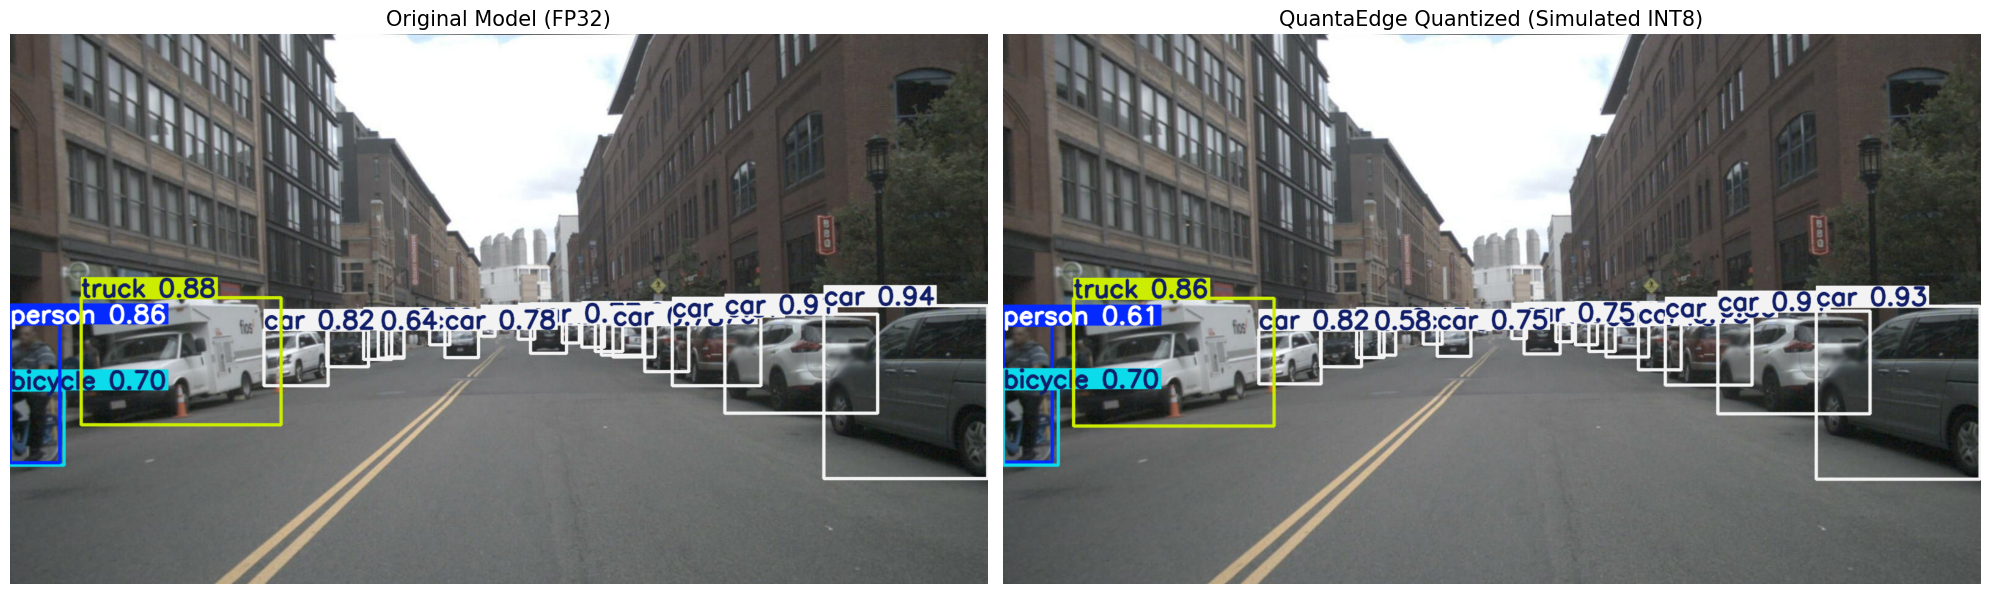

In [9]:
# Select a challenging nuScenes frame
test_image_path = sample_images[15] 

# Prepare the high-level wrapper for the quantized model
# We create a new YOLO object and swap its internal model with our 'model_quant'
quant_wrapper = YOLO(MODEL_PATH)
quant_wrapper.model = model_quant # This is our Backbone+Neck+KL Head model

# Generate Visuals
print(f"--- Generating Visual Comparison for {test_image_path} ---")
img_fp32 = get_annotated_frame(YOLO(MODEL_PATH), test_image_path)
img_int8 = get_annotated_frame(quant_wrapper, test_image_path)

# Plot Side-by-Side
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_fp32, cv2.COLOR_BGR2RGB))
plt.title("Original Model (FP32)", fontsize=15)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_int8, cv2.COLOR_BGR2RGB))
plt.title("QuantaEdge Quantized (Simulated INT8)", fontsize=15)
plt.axis('off')

plt.tight_layout()
plt.show()

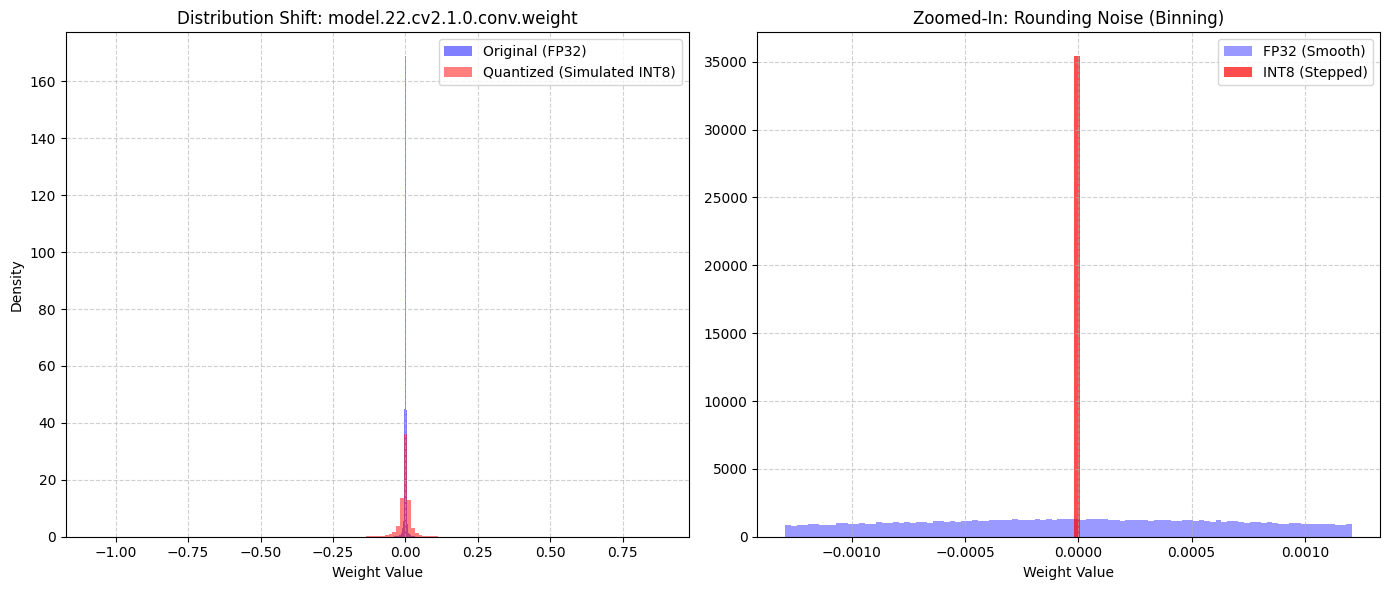

In [10]:
#Assuming 'model_ref' (FP32) and 'model_quant' (Quantized) are in memory
TARGET_LAYER = "model.22.cv2.1.0.conv.weight"

def plot_quantization_impact(model_fp32, model_int8, layer_name):
    '''Plot the change in distribution'''
    # Extract weights
    w_fp32 = model_fp32.state_dict()[layer_name].detach().cpu().numpy().flatten()
    w_int8 = model_int8.state_dict()[layer_name].detach().cpu().numpy().flatten()
    
    plt.figure(figsize=(14, 6))
    
    # 1. Histogram Comparison
    plt.subplot(1, 2, 1)
    plt.hist(w_fp32, bins=150, alpha=0.5, label='Original (FP32)', color='blue', density=True)
    plt.hist(w_int8, bins=150, alpha=0.5, label='Quantized (Simulated INT8)', color='red', density=True)
    
    plt.title(f"Distribution Shift: {layer_name}")
    plt.xlabel("Weight Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 2. "Zoomed In" Comparison to see the Bins
    plt.subplot(1, 2, 2)
    # Focus on the 'meat' of the distribution
    zoom_range = (np.percentile(w_fp32, 25), np.percentile(w_fp32, 75))
    plt.hist(w_fp32, bins=100, range=zoom_range, alpha=0.4, label='FP32 (Smooth)', color='blue')
    plt.hist(w_int8, bins=100, range=zoom_range, alpha=0.7, label='INT8 (Stepped)', color='red')
    
    plt.title("Zoomed-In: Rounding Noise (Binning)")
    plt.xlabel("Weight Value")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Run the visualization
plot_quantization_impact(model_ref, model_quant, TARGET_LAYER)

### 4. Deployment 

Ensure the deployment tool (like TensorRT, ANE) supports "Layer-wise Precision." Most modern tools do, but we usually have to pass a "precision map" or a list of "node-specific constraints" during the conversion process.

#### ONXX for cross-platform capibilities

In [11]:
model_quant.eval()
dummy_input = torch.randn(1, 3, 640, 640).to(device)

print("\n--- Exporting to ONNX (Clean Opset 18) ---")
torch.onnx.export(
    model_quant, 
    dummy_input, 
    "models/quantaedge_yolov8m_simulated.onnx",
    verbose=False,
    opset_version=18, 
    input_names=['images'],
    output_names=['output0'],
    dynamic_axes={'images': {0: 'batch'}, 'output0': {0: 'batch'}}
)
print("Success: Clean Opset 18 ONNX saved.")


--- Exporting to ONNX (Clean Opset 18) ---
Applied 9 of general pattern rewrite rules.
Success: Clean Opset 18 ONNX saved.


Technically, our .onnx file is still an FP32 file. It does not contain QuantizeLinear or DequantizeLinear nodes. These are special ONNX instructions that tell a chip like an Nvidia GPU or an NPU to "Switch to Integer Math mode now."

#### CoreML for ANE

In [13]:
# 1. Define the Sanitizer Wrapper
class YOLOANEWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # Run the model
        output = self.model(x)
        
        # YOLOv8 often returns (Tensor, Dict) or (Tensor, List)
        # We only want the first element: the raw prediction tensor [Batch, 84, 8400]
        if isinstance(output, (list, tuple)):
            return output[0]
        return output

# 2. Prepare for Export
model_quant.cpu() # Move to CPU for stable tracing
dummy_input = torch.randn(1, 3, 640, 640)
wrapper = YOLOANEWrapper(model_quant).eval()

print("--- Tracing Sanitized Model ---")
# Use strict=False to allow the tracer to ignore non-tensor logic if any remains
traced_model = torch.jit.trace(wrapper, dummy_input, strict=False)

# 3. CoreML Conversion (Direct Path)
print("--- Converting to CoreML ---")

# We define the scale and bias so the ANE handles normalization
inputs = [ct.ImageType(name="images", 
                       shape=(1, 3, 640, 640), 
                       scale=1.0/255.0, 
                       color_layout=ct.colorlayout.RGB)]

mlmodel = ct.convert(
    traced_model,
    inputs=inputs,
    compute_units=ct.ComputeUnit.ALL, 
    minimum_deployment_target=ct.target.macOS14
)

mlmodel.save("models/QuantaEdge_YOLOv8m.mlpackage")
print("\nSuccess: QuantaEdge_YOLOv8m.mlpackage generated.")

--- Tracing Sanitized Model ---
--- Converting to CoreML ---


Converting PyTor
Running MIL fron
Running MIL defa
Running MIL back



Success: QuantaEdge_YOLOv8m.mlpackage generated.


The Apple compiler will see that weights are already distributed perfectly for 8-bit math. It will map them to the ANE's internal 8-bit or 16-bit engines with almost zero additional accuracy loss.



### 5. Latency Comparison

#### Running Quantized YOLO on ANU

In [14]:
# 1. Load the model
model_path = "models/QuantaEdge_YOLOv8m.mlpackage"
print(f"--- Loading Model: {model_path} ---")
model = ct.models.MLModel(model_path, compute_units=ct.ComputeUnit.ALL)

# 2. Prepare PIL Dummy Input
# Create a random RGB image of size 640x640
input_shape = (640, 640)
random_data = np.random.randint(0, 255, (input_shape[0], input_shape[1], 3), dtype=np.uint8)
dummy_input = Image.fromarray(random_data)

# 3. Benchmark Configuration
num_warmup = 20
num_runs = 100
latencies = []

print(f"--- Starting Benchmark ({num_runs} iterations) ---")

# Warm-up Phase
for i in range(num_warmup):
    # CoreML expects the key 'images' as defined in our export
    _ = model.predict({"images": dummy_input})

# Measurement Phase
for i in range(num_runs):
    start_time = time.perf_counter()
    _ = model.predict({"images": dummy_input})
    end_time = time.perf_counter()
    latencies.append((end_time - start_time) * 1000)

# 4. Final Report
avg_latency = np.mean(latencies)
fps = 1000 / avg_latency

print("\n" + "="*50)
print(f"Average Latency:    {avg_latency:.2f} ms")
print(f"Throughput (FPS):   {fps:.2f} FPS")
print("="*50)

--- Loading Model: models/QuantaEdge_YOLOv8m.mlpackage ---
--- Starting Benchmark (100 iterations) ---

Average Latency:    7.38 ms
Throughput (FPS):   135.55 FPS


#### Running Quantized YOLO on MPS

In [15]:
# 1. Load the model
model_path = "models/QuantaEdge_YOLOv8m.mlpackage"
print(f"--- Loading Model: {model_path} ---")
model = ct.models.MLModel(model_path, compute_units=ct.ComputeUnit.CPU_AND_GPU)

# 2. Prepare PIL Dummy Input
# Create a random RGB image of size 640x640
input_shape = (640, 640)
random_data = np.random.randint(0, 255, (input_shape[0], input_shape[1], 3), dtype=np.uint8)
dummy_input = Image.fromarray(random_data)

# 3. Benchmark Configuration
num_warmup = 20
num_runs = 100
latencies = []

print(f"--- Starting Benchmark ({num_runs} iterations) ---")

# Warm-up Phase
for i in range(num_warmup):
    # CoreML expects the key 'images' as defined in our export
    _ = model.predict({"images": dummy_input})

# Measurement Phase
for i in range(num_runs):
    start_time = time.perf_counter()
    _ = model.predict({"images": dummy_input})
    end_time = time.perf_counter()
    latencies.append((end_time - start_time) * 1000)

# 4. Final Report
avg_latency = np.mean(latencies)
fps = 1000 / avg_latency

print("\n" + "="*50)
print(f"Average Latency:    {avg_latency:.2f} ms")
print(f"Throughput (FPS):   {fps:.2f} FPS")
print("="*50)

--- Loading Model: models/QuantaEdge_YOLOv8m.mlpackage ---
--- Starting Benchmark (100 iterations) ---

Average Latency:    25.79 ms
Throughput (FPS):   38.77 FPS


#### Running Original YOLO on MPS

In [16]:
# 1. Configuration
MODEL_PATH = 'models/yolov8m.pt'
NUM_WARMUP = 20
NUM_RUNS = 100
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

# 2. Load Original Model
print(f"--- Loading Original Model: {MODEL_PATH} on {device} ---")
model = YOLO(MODEL_PATH).model.to(device).eval()

# 3. Prepare Dummy Input
# Standard YOLOv8 input tensor [Batch, Channel, Height, Width]
dummy_input = torch.randn(1, 3, 640, 640).to(device)

# 4. Benchmark
latencies = []

print(f"--- Starting PyTorch Benchmark ({NUM_RUNS} iterations) ---")

with torch.no_grad():
    # Warm-up (Crucial for MPS shader compilation)
    for _ in range(NUM_WARMUP):
        _ = model(dummy_input)
    
    # Measurement
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        _ = model(dummy_input)
        # We call synchronize to ensure the GPU finishes the task before we stop the clock
        torch.mps.synchronize() 
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)

# 5. Final Report
avg_latency_pt = np.mean(latencies)
fps_pt = 1000 / avg_latency_pt

print("\n" + "="*50)
print(f"{'PyTorch (.pt) Performance Report':^50}")
print("-" * 50)
print(f"Average Latency:    {avg_latency_pt:.2f} ms")
print(f"Throughput (FPS):   {fps_pt:.2f} FPS")
print("="*50)

--- Loading Original Model: models/yolov8m.pt on mps ---
--- Starting PyTorch Benchmark (100 iterations) ---

         PyTorch (.pt) Performance Report         
--------------------------------------------------
Average Latency:    45.62 ms
Throughput (FPS):   21.92 FPS


Stage,Model & Hardware,Latency,Speedup (Incremental),What changed?

Baseline,PyTorch (FP32) on GPU,45.67 ms,1.0x,Standard starting point.

Step 1,CoreML (Quantized) on GPU,25.50 ms,~1.8x,Software Gain: Better compiler (CoreML) + INT8/FP16 weight throughput.

Step 2,CoreML (Quantized) on ANE,7.23 ms,~3.5x,Hardware Gain: Moving from General Purpose GPU to Dedicated NPU (Neural Engine).

### 6. MaP Validation

In [17]:
# ==========================================
# 1. Setup Both Models & Metrics
# ==========================================
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

print("--- Loading Models ---")
# Model A: The Original Baseline
model_pt = YOLO("models/yolov8m.pt").model.to(device).eval()
metric_pt = MeanAveragePrecision()

# Model B: The QuantaEdge Optimized Model
model_ml = ct.models.MLModel("models/QuantaEdge_YOLOv8m.mlpackage", compute_units=ct.ComputeUnit.ALL)
metric_ml = MeanAveragePrecision()

# ==========================================
# 2. nuScenes Setup & Mappings
# ==========================================
DATAROOT = '../AV/data/sets/nuscenes'
nusc = NuScenes(version='v1.0-mini', dataroot=DATAROOT, verbose=False)

COCO_MAPPING = {
    'human.pedestrian.adult': 0, 'human.pedestrian.child': 0, 
    'human.pedestrian.construction_worker': 0, 'human.pedestrian.police_officer': 0,
    'vehicle.bicycle': 1, 'vehicle.car': 2, 'vehicle.motorcycle': 3,
    'vehicle.bus.bendy': 5, 'vehicle.bus.rigid': 5, 'vehicle.truck': 7, 'vehicle.trailer': 7
}

# (Keep the helper functions: post_process, scale_boxes, get_2d_ground_truth the same as before)
def post_process(prediction, conf_thres=0.25, iou_thres=0.45):
    prediction = torch.from_numpy(prediction).squeeze(0).T
    scores, labels = prediction[:, 4:].max(1)
    mask = scores > conf_thres
    prediction, scores, labels = prediction[mask], scores[mask], labels[mask]
    if prediction.shape[0] == 0: return torch.empty((0, 4)), torch.empty(0), torch.empty(0)
    boxes = prediction[:, :4]
    x1y1 = boxes[:, :2] - boxes[:, 2:] / 2
    x2y2 = boxes[:, :2] + boxes[:, 2:] / 2
    boxes = torch.cat((x1y1, x2y2), dim=1)
    keep = nms(boxes, scores, iou_thres)
    return boxes[keep], scores[keep], labels[keep]

def scale_boxes(boxes, orig_w=1600, orig_h=900, pred_w=640, pred_h=640):
    if boxes.shape[0] == 0: return boxes
    scale_x, scale_y = orig_w / pred_w, orig_h / pred_h
    boxes[:, 0] *= scale_x; boxes[:, 2] *= scale_x
    boxes[:, 1] *= scale_y; boxes[:, 3] *= scale_y
    return boxes

def get_2d_ground_truth(nusc, sample_data_token):
    data_path, boxes_3d, camera_intrinsic = nusc.get_sample_data(sample_data_token)
    gt_boxes, gt_labels = [], []
    for box in boxes_3d:
        if box.name not in COCO_MAPPING: continue
        corners = view_points(box.corners(), camera_intrinsic, normalize=True)[:2, :]
        x1, x2 = corners[0].min(), corners[0].max()
        y1, y2 = corners[1].min(), corners[1].max()
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(1600, x2), min(900, y2)
        if x2 > x1 and y2 > y1:
            gt_boxes.append([x1, y1, x2, y2])
            gt_labels.append(COCO_MAPPING[box.name])
    if not gt_boxes: return torch.empty((0, 4)), torch.empty(0, dtype=torch.int64), data_path
    return torch.tensor(gt_boxes, dtype=torch.float32), torch.tensor(gt_labels, dtype=torch.int64), data_path

# ==========================================
# 3. Side-by-Side A/B Validation Loop
# ==========================================
print(f"\n--- Starting A/B mAP Evaluation on nuScenes ---")
limit = 500 
count = 0

for sample in tqdm(nusc.sample):
    if count >= limit: break
    cam_front_token = sample['data']['CAM_FRONT']
    gt_boxes, gt_labels, img_path = get_2d_ground_truth(nusc, cam_front_token)
    
    # Pre-process Image
    img_pil = Image.open(img_path).resize((640, 640))
    targets = [{'boxes': gt_boxes, 'labels': gt_labels}]
    
    # ----------------------------------
    # INFERENCE A: PyTorch Baseline (FP32)
    # ----------------------------------
    # PyTorch needs the image as a normalized tensor
    img_tensor = torch.from_numpy(np.array(img_pil)).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0
    with torch.no_grad():
        raw_out_pt = model_pt(img_tensor)[0].cpu().numpy()
    
    p_boxes_pt, p_scores_pt, p_labels_pt = post_process(raw_out_pt)
    preds_pt = [{'boxes': scale_boxes(p_boxes_pt), 'scores': p_scores_pt, 'labels': p_labels_pt}]
    metric_pt.update(preds_pt, targets)
    
    # ----------------------------------
    # INFERENCE B: CoreML QuantaEdge (INT8/FP16)
    # ----------------------------------
    # CoreML needs the raw PIL image (it handles normalization via hardware)
    raw_out_ml = list(model_ml.predict({"images": img_pil}).values())[0]
    
    p_boxes_ml, p_scores_ml, p_labels_ml = post_process(raw_out_ml)
    preds_ml = [{'boxes': scale_boxes(p_boxes_ml), 'scores': p_scores_ml, 'labels': p_labels_ml}]
    metric_ml.update(preds_ml, targets)
    
    count += 1

# ==========================================
# 4. Compute and Compare Delta
# ==========================================
res_pt = metric_pt.compute()
res_ml = metric_ml.compute()

map50_pt = res_pt['map_50'].item()
map50_ml = res_ml['map_50'].item()
delta_map50 = map50_ml - map50_pt

map_pt = res_pt['map'].item()
map_ml = res_ml['map'].item()
delta_map = map_ml - map_pt

print("\n" + "="*55)
print(f"{'QuantaEdge A/B Accuracy Report':^55}")
print("-" * 55)
print(f"{'Metric':<15} | {'Original (FP32)':<15} | {'CoreML (INT8)':<15} | {'Delta'}")
print("-" * 55)
print(f"{'mAP @ .50':<15} | {map50_pt:<15.4f} | {map50_ml:<15.4f} | {delta_map50:+.4f}")
print(f"{'mAP @ .50:.95':<15} | {map_pt:<15.4f} | {map_ml:<15.4f} | {delta_map:+.4f}")
print("="*55)

--- Loading Models ---

--- Starting A/B mAP Evaluation on nuScenes ---


100%|█| 404/404 



            QuantaEdge A/B Accuracy Report             
-------------------------------------------------------
Metric          | Original (FP32) | CoreML (INT8)   | Delta
-------------------------------------------------------
mAP @ .50       | 0.2273          | 0.2117          | -0.0156
mAP @ .50:.95   | 0.1046          | 0.1010          | -0.0036


### 7. Model Size

In [18]:
def get_size_on_disk(path):
    if os.path.isfile(path):
        # Logical size of a single file
        return os.path.getsize(path)
    elif os.path.isdir(path):
        # Recursive size for directory-based models
        total_size = 0
        for dirpath, dirnames, filenames in os.walk(path):
            for f in filenames:
                fp = os.path.join(dirpath, f)
                # skip if it is symbolic link
                if not os.path.islink(fp):
                    total_size += os.path.getsize(fp)
        return total_size

# Example Comparison
size_a = get_size_on_disk("models/QuantaEdge_YOLOv8m.mlpackage/")
size_b = get_size_on_disk("models/yolov8m.pt")

print(f"Model A: {size_a / (1024**2):.2f} MB")
print(f"Model B: {size_b / (1024**2):.2f} MB")
print(f"Reduction: {(1 - size_b/size_a)*100:.2f}%")

Model A: 49.58 MB
Model B: 49.72 MB
Reduction: -0.29%


In [19]:
# 1. Load your existing "Fake Quantized" model
# This model has the right numbers, but in 32-bit "cups"
model = ct.models.MLModel("models/QuantaEdge_YOLOv8m.mlpackage")

print("--- Starting Weight Compression (Storage Pass) ---")

# 2. Define the Linear Quantization Config
# We use 'linear_symmetric' to match the Min-Max/Clipped work from our notebook
config = cmo.OptimizationConfig(
    global_config=cmo.OpLinearQuantizerConfig(
        mode="linear_symmetric", 
        weight_threshold=512  # Ensures we only compress actual weight tensors
    )
)

# 3. The Corrected Function Name: linear_quantize_weights
# This physically casts those 32-bit floats into 8-bit integers on disk
compressed_model = cmo.linear_quantize_weights(model, config=config)

# 4. Save the result
compressed_model.save("models/QuantaEdge_YOLOv8m_INT8.mlpackage")

# 5. Final Size Check
def get_size(path):
    import os
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            total += os.path.getsize(os.path.join(dirpath, f))
    return total / (1024**2)

print(f"\nOriginal Size:   {get_size('models/QuantaEdge_YOLOv8m.mlpackage'):.2f} MB")
print(f"Compressed Size: {get_size('models/QuantaEdge_YOLOv8m_INT8.mlpackage'):.2f} MB")

--- Starting Weight Compression (Storage Pass) ---


Running compress
Running MIL frontend_milinternal pipeline: 0 passes [00:00, ? passes/s]
Running MIL defa
Running MIL back



Original Size:   49.58 MB
Compressed Size: 24.94 MB


In [20]:
((24.94-49.58)*100)/49.58

-49.69745865268253

### 8. Test Quantized Model on a scene

In [32]:
# ==========================================
# 1. CONFIGURATION & DATASET INIT
# ==========================================
# Update these paths to match your Bangalore setup
DATAROOT = '../AV/data/sets/nuscenes'
MODEL_PATH = "models/QuantaEdge_YOLOv8m_INT8.mlpackage"
OUTPUT_VIDEO = "QuantaEdge_nuScenes_Validation_2.mp4"

# Standard YOLO to nuScenes class mapping (Simplified)
CLASS_NAMES = {0: 'pedestrian', 2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}
CONF_THRESHOLD = 0.40
NMS_THRESHOLD = 0.45

# Initialize nuScenes
nusc = NuScenes(version='v1.0-mini', dataroot=DATAROOT, verbose=False)

# Load Optimized CoreML Model
print(f"--- Loading Surgical Quantized Model: {MODEL_PATH} ---")
model = ct.models.MLModel(MODEL_PATH)

# ==========================================
# 2. SELECT SCENE & PREPARE VIDEO
# ==========================================
# scene-0061 is a classic urban driving sequence in nuScenes
scene = nusc.scene[0] 
current_sample_token = scene['first_sample_token']

# Setup Video Writer (Match nuScenes CAM_FRONT resolution)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 12, (1600, 900))

print(f"Processing Scene: {scene['name']} ({scene['description']})")

# ==========================================
# 3. CORE INFERENCE LOOP
# ==========================================
frame_count = 0

try:
    while current_sample_token != '':
        sample = nusc.get('sample', current_sample_token)
        cam_data = nusc.get('sample_data', sample['data']['CAM_FRONT'])
        img_path = os.path.join(DATAROOT, cam_data['filename'])
        
        # Load Image
        raw_img = Image.open(img_path)
        # YOLOv8 expects 640x640 input
        input_img = raw_img.resize((640, 640))
        
        # --- ANE INFERENCE ---
        start_time = time.perf_counter()
        # Use 'images' key as identified in previous error
        prediction = model.predict({'images': input_img}) 
        end_time = time.perf_counter()
        
        latency = (end_time - start_time) * 1000
        fps = 1 / (end_time - start_time)
        
        # --- POST-PROCESSING (Vectorized) ---
        output_key = list(prediction.keys())[0]
        raw_output = prediction[output_key] # Shape: (1, 84, 8400)
        
        # Transpose and remove batch dim
        preds = np.squeeze(raw_output).T # Shape: (8400, 84)
        
        # Extract Boxes and Scores
        boxes = preds[:, :4]
        scores = preds[:, 4:]
        class_ids = np.argmax(scores, axis=1)
        confidences = np.max(scores, axis=1)
        
        # Filter by Confidence
        mask = confidences > CONF_THRESHOLD
        boxes = boxes[mask]
        confidences = confidences[mask]
        class_ids = class_ids[mask]
        
        # Convert [cx, cy, w, h] to [x1, y1, w, h] for NMS
        # Scale to 1600x900 nuScenes resolution
        scale_x, scale_y = 1600 / 640, 900 / 640
        final_boxes = []
        for b in boxes:
            x = (b[0] - b[2]/2) * scale_x
            y = (b[1] - b[3]/2) * scale_y
            w = b[2] * scale_x
            h = b[3] * scale_y
            final_boxes.append([int(x), int(y), int(w), int(h)])
            
        # Run NMS (To prevent overlapping boxes on the same car)
        indices = cv2.dnn.NMSBoxes(final_boxes, confidences, CONF_THRESHOLD, NMS_THRESHOLD)
        
        # --- VISUALIZATION ---
        frame = cv2.imread(img_path)
        
        if len(indices) > 0:
            for i in indices.flatten():
                x, y, w, h = final_boxes[i]
                cls_id = class_ids[i]
                label = CLASS_NAMES.get(cls_id, f"ID:{cls_id}")
                
                # BMW-Style Blue/Orange Bounding Boxes
                color = (255, 128, 0) if cls_id == 2 else (0, 255, 255) # Orange for cars
                cv2.rectangle(frame, (x, y), (x + w, y + h), color, 3)
                cv2.putText(frame, f"{label} {confidences[i]:.2f}", (x, y - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # Performance Overlay (The most important part for the interview)
        overlay_text = f"QuantaEdge ANE: {latency:.2f}ms | {fps:.1f} FPS"
        cv2.rectangle(frame, (30, 20), (650, 80), (0, 0, 0), -1) # Dark background for text
        cv2.putText(frame, overlay_text, (50, 60), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

        video_writer.write(frame)
        current_sample_token = sample['next']
        frame_count += 1
        if frame_count % 10 == 0:
            print(f"Processed {frame_count} frames...")

finally:
    video_writer.release()
    print(f"\nSUCCESS: Video saved to {OUTPUT_VIDEO}")
    print(f"Final Performance: Avg {latency:.2f}ms on Apple M4 Neural Engine")

--- Loading Surgical Quantized Model: models/QuantaEdge_YOLOv8m_INT8.mlpackage ---
Processing Scene: scene-0061 (Parked truck, construction, intersection, turn left, following a van)
Processed 10 frames...
Processed 20 frames...
Processed 30 frames...

SUCCESS: Video saved to QuantaEdge_nuScenes_Validation_2.mp4
Final Performance: Avg 7.08ms on Apple M4 Neural Engine


### 9. Test FP32 Model on a scene

In [36]:
import os
import cv2
import time
import torch
import numpy as np
from ultralytics import YOLO
from nuscenes.nuscenes import NuScenes

# ==========================================
# 1. CONFIGURATION & DEVICE SETUP
# ==========================================
DATAROOT = '../AV/data/sets/nuscenes'
MODEL_PATH = "models/yolov8m.pt"  # The original PyTorch model
OUTPUT_VIDEO = "Baseline_YOLO_MPS.mp4"

# Set device to MPS (Metal Performance Shaders)
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"--- Target Device: {device.upper()} ---")

# Initialize nuScenes
nusc = NuScenes(version='v1.0-mini', dataroot=DATAROOT, verbose=False)

# Load the original model
print(f"--- Loading Baseline Model: {MODEL_PATH} ---")
model = YOLO(MODEL_PATH)
model.to(device) # Ensure model is moved to GPU memory

# ==========================================
# 2. SELECT SCENE & PREPARE VIDEO
# ==========================================
scene = nusc.scene[0] 
current_sample_token = scene['first_sample_token']

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 12, (1600, 900))

print(f"Processing Scene for Baseline: {scene['name']}")

# ==========================================
# 3. CORE INFERENCE LOOP
# ==========================================
frame_count = 0

try:
    while current_sample_token != '':
        sample = nusc.get('sample', current_sample_token)
        cam_data = nusc.get('sample_data', sample['data']['CAM_FRONT'])
        img_path = os.path.join(DATAROOT, cam_data['filename'])
        
        # Load frame for visualization
        frame = cv2.imread(img_path)
        
        # --- GPU INFERENCE ---
        start_time = time.perf_counter()
        # We specify device='mps' here
        results = model.predict(
            source=img_path, 
            device=device,
            imgsz=640, 
            conf=0.40, 
            verbose=False
        )
        end_time = time.perf_counter()
        
        latency = (end_time - start_time) * 1000
        fps = 1 / (end_time - start_time)
        
        # --- VISUALIZATION ---
        boxes = results[0].boxes
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = box.conf[0].item()
            cls = int(box.cls[0].item())
            label = model.names[cls]
            
            # Use a different color (e.g., Red) to distinguish Baseline from Optimized
            color = (0, 0, 255) # Red for Baseline
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
            cv2.putText(frame, f"{label} {conf:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # Performance Overlay (Labelled as MPS/GPU)
        overlay_text = f"Baseline MPS (GPU): {latency:.2f}ms | {fps:.1f} FPS"
        cv2.rectangle(frame, (30, 20), (850, 80), (0, 0, 150), -1) 
        cv2.putText(frame, overlay_text, (50, 60), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3)

        video_writer.write(frame)
        
        current_sample_token = sample['next']
        frame_count += 1
        if frame_count % 10 == 0:
            print(f"Processed {frame_count} frames on MPS...")

finally:
    video_writer.release()
    print(f"\nSUCCESS: Baseline video saved to {OUTPUT_VIDEO}")
    print(f"Final Performance: Avg {latency:.2f}ms on Apple GPU (MPS)")

--- Target Device: MPS ---
--- Loading Baseline Model: models/yolov8m.pt ---
Processing Scene for Baseline: scene-0061
Processed 10 frames on MPS...
Processed 20 frames on MPS...
Processed 30 frames on MPS...

SUCCESS: Baseline video saved to Baseline_YOLO_MPS.mp4
Final Performance: Avg 33.19ms on Apple GPU (MPS)
